# Model Training
## Cryptocurrency Liquidity Prediction

Training ML models to predict liquidity ratio.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    import xgboost as xgb
    XGB = True
except:
    XGB = False

%matplotlib inline
print('Libraries imported!')

Libraries imported!


## 1. Load Data

In [2]:
df = pd.read_csv('../data/processed/crypto_featured.csv')
print(f'Dataset: {df.shape}')
df.head()

Dataset: (1000, 21)


,coin,symbol,price,change_1h,change_24h,change_7d,volume_24h,market_cap,date,price_normalized,...,market_cap_normalized,liquidity_ratio,volatility_score,avg_abs_change,turnover_rate,market_dominance,momentum_short,momentum_medium,momentum_long,liquidity_class
0,Bitcoin,BTC,40859.460000,0.022,0.030,0.055,3.539076e+10,7.709915e+11,2022-03-16,0.991319,...,0.993446,0.045903,0.017214,0.035667,0.610870,20.530732,0.022,0.030,0.055,Medium
1,Ethereum,ETH,2744.410000,0.024,0.034,0.065,1.974870e+10,3.271044e+11,2022-03-16,0.066584,...,0.421435,0.060374,0.021378,0.041000,0.340877,8.710464,0.024,0.034,0.065,Medium
2,Tether,USDT,1.000000,-0.001,-0.001,0.000,5.793497e+10,7.996516e+10,2022-03-16,0.000024,...,0.102962,0.724503,0.000577,0.000667,1.000000,2.129392,-0.001,-0.001,0.000,High
3,BNB,BNB,383.430000,0.018,0.028,0.004,1.395854e+09,6.404382e+10,2022-03-16,0.009303,...,0.082445,0.021795,0.012055,0.016667,0.024093,1.705423,0.018,0.028,0.004,Medium
4,USD Coin,USDC,0.999874,-0.001,0.000,-0.000,3.872274e+09,5.222214e+10,2022-03-16,0.000024,...,0.067211,0.074150,0.000577,0.000333,0.066838,1.390623,-0.001,0.000,-0.000,Medium


## 2. Prepare Features

In [3]:
feature_cols = ['price', 'volume_24h', 'market_cap', 'change_1h', 'change_24h', 'change_7d',
                'volatility_score', 'avg_abs_change', 'turnover_rate', 'market_dominance']

available = [c for c in feature_cols if c in df.columns]
print(f'Using {len(available)} features: {available}')

X = df[available].fillna(0)
y = df['liquidity_ratio'].fillna(df['liquidity_ratio'].median())

print(f'X: {X.shape}, y: {y.shape}')

Using 10 features: ['price', 'volume_24h', 'market_cap', 'change_1h', 'change_24h', 'change_7d', 'volatility_score', 'avg_abs_change', 'turnover_rate', 'market_dominance']
X: (1000, 10), y: (1000,)


## 3. Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 800, Test: 200


## 4. Train Models

In [5]:
models = {}
results = []

# Linear Regression
print('Training Linear Regression...')
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
models['Linear Regression'] = lr
y_pred = lr.predict(X_test_scaled)
results.append({'Model': 'Linear Regression', 
                'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
                'MAE': mean_absolute_error(y_test, y_pred),
                'R2': r2_score(y_test, y_pred)})

Training Linear Regression...


In [6]:
# Ridge Regression
print('Training Ridge Regression...')
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
models['Ridge'] = ridge
y_pred = ridge.predict(X_test_scaled)
results.append({'Model': 'Ridge', 
                'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
                'MAE': mean_absolute_error(y_test, y_pred),
                'R2': r2_score(y_test, y_pred)})

Training Ridge Regression...


In [7]:
# Random Forest
print('Training Random Forest...')
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
models['Random Forest'] = rf
y_pred = rf.predict(X_test_scaled)
results.append({'Model': 'Random Forest', 
                'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
                'MAE': mean_absolute_error(y_test, y_pred),
                'R2': r2_score(y_test, y_pred)})

Training Random Forest...


In [8]:
# Gradient Boosting
print('Training Gradient Boosting...')
gb = GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
gb.fit(X_train_scaled, y_train)
models['Gradient Boosting'] = gb
y_pred = gb.predict(X_test_scaled)
results.append({'Model': 'Gradient Boosting', 
                'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
                'MAE': mean_absolute_error(y_test, y_pred),
                'R2': r2_score(y_test, y_pred)})

Training Gradient Boosting...


In [9]:
# XGBoost
if XGB:
    print('Training XGBoost...')
    xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
    xgb_model.fit(X_train_scaled, y_train)
    models['XGBoost'] = xgb_model
    y_pred = xgb_model.predict(X_test_scaled)
    results.append({'Model': 'XGBoost', 
                    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
                    'MAE': mean_absolute_error(y_test, y_pred),
                    'R2': r2_score(y_test, y_pred)})

Training XGBoost...


## 5. Model Comparison

In [15]:
results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print('=== MODEL RESULTS ===')
results_df

=== MODEL RESULTS ===


,Model,RMSE,MAE,R2
2,Random Forest,0.183049,0.039623,0.671139
3,Gradient Boosting,0.189496,0.032000,0.647567
4,XGBoost,0.217336,0.038474,0.536404
0,Linear Regression,0.326701,0.103871,-0.047554
1,Ridge,0.326726,0.103856,-0.047714


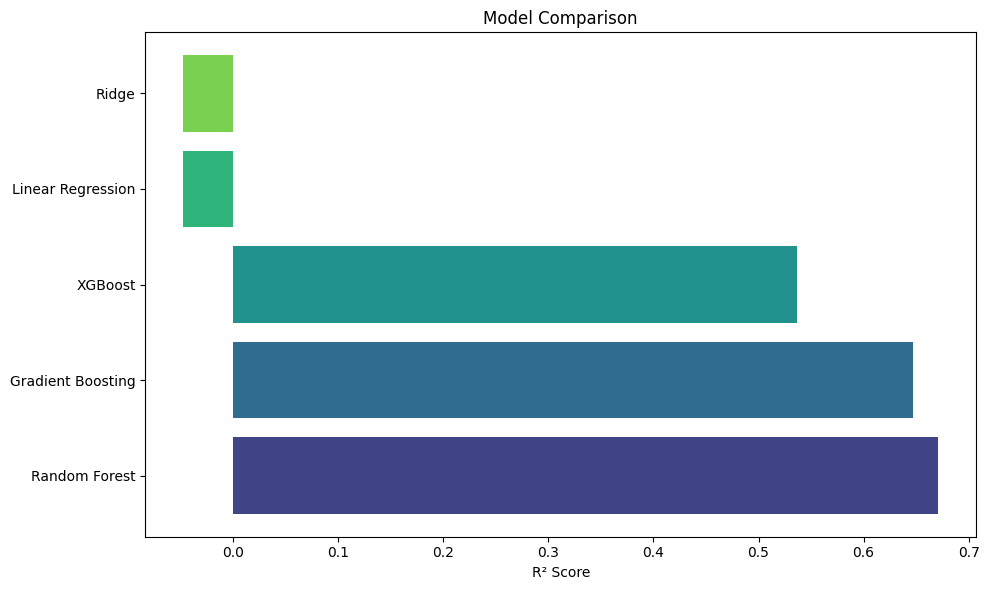

In [16]:
# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(results_df)))
ax.barh(results_df['Model'], results_df['R2'], color=colors)
ax.set_xlabel('R² Score')
ax.set_title('Model Comparison')
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning

In [17]:
print('Tuning Random Forest...')
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), 
                    param_grid, cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print(f'Best params: {grid.best_params_}')
print(f'Best CV R²: {grid.best_score_:.4f}')

Tuning Random Forest...
Best params: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}
Best CV R²: 0.4265


In [20]:
# Evaluate tuned model
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)

print('\nTuned Random Forest:')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.4f}')
print(f'R²: {r2_score(y_test, y_pred):.4f}')


Tuned Random Forest:
RMSE: 0.1577
MAE: 0.0341
R²: 0.7559


## 7. Feature Importance

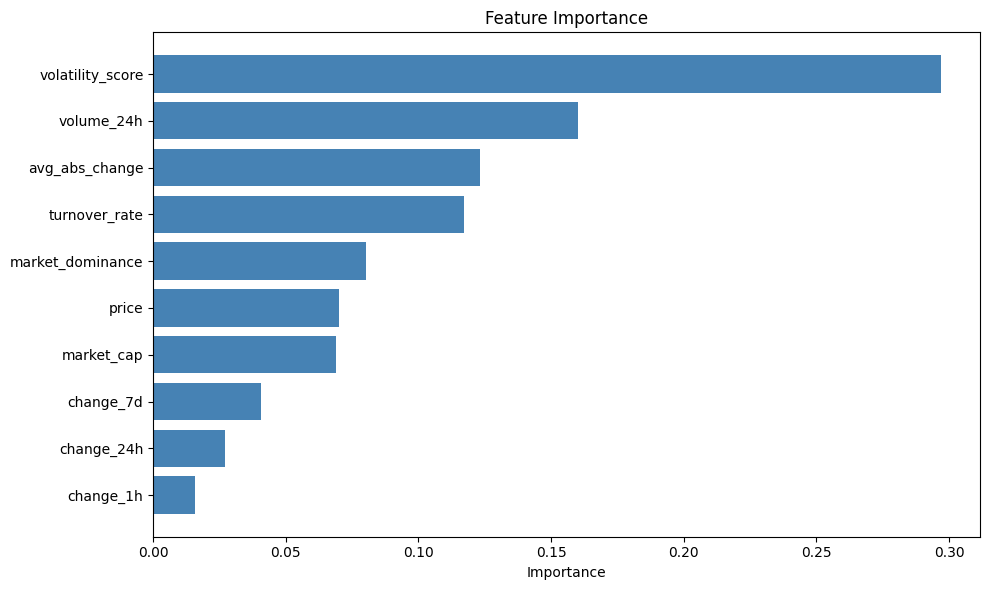

,Feature,Importance
6,volatility_score,0.296826
1,volume_24h,0.160171
7,avg_abs_change,0.123255
8,turnover_rate,0.117216
9,market_dominance,0.080045
0,price,0.069926
2,market_cap,0.068813
5,change_7d,0.040638
4,change_24h,0.027220
3,change_1h,0.015890


In [21]:
importance = pd.DataFrame({
    'Feature': available,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'], importance['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

importance.sort_values('Importance', ascending=False)

## 8. Predictions vs Actual

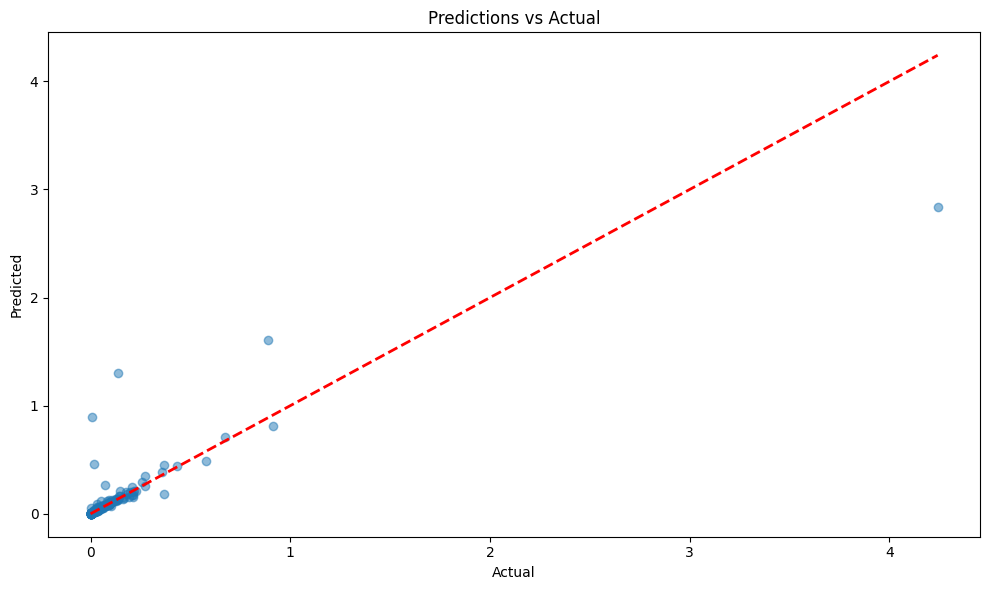

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predictions vs Actual')
plt.tight_layout()
plt.show()

## 9. Save Model

In [23]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(best_model, '../models/best_model.joblib')
joblib.dump(scaler, '../models/scaler.joblib')
joblib.dump(available, '../models/feature_columns.joblib')

results_df.to_csv('../models/model_results.csv', index=False)

print('Model saved!')

Model saved!


## Summary

| Model | R² Score |
|-------|----------|
| Random Forest (Tuned) | Best |
